# Torque-Speed Maps — Healthy and Fault Modes

Computes and plots the operating-regime segment map for the 5-phase PMSM
in four fault configurations using `current_setpoints_new`:

- Healthy (no fault)
- 1 open phase (phase 0)
- 2 adjacent open phases (phases 0 and 1)
- 2 non-adjacent open phases (phases 0 and 2)

In [1]:
import os
import pickle
import sys

import numpy as np

root_dir = os.path.abspath("..")
data_dir = os.path.join(root_dir, "data")
os.makedirs(data_dir, exist_ok=True)
if root_dir not in sys.path:
    sys.path.append(root_dir)

from current_setpoints_new.models.machines import PMSM5Phase
from current_setpoints_new.models.forward_model import ForwardModel, Fault
from current_setpoints_new.optimization.optimizer import StaticOptimizer
from current_setpoints_new.optimization.grid import calculate_grid
from current_setpoints_new.optimization.data import grid_to_data
from current_setpoints_new.utils.plotting import plot_grid_segments

In [2]:
CURR_MAX  = 30.0
VOLT_MAX  = 13.0
OMEGA_MAX = 1800.0  # mechanical RPM

SLSQP_OPTS = {"method": "SLSQP", "options": {"ftol": 1e-8, "maxiter": 500}}
GRID_OPTS  = {"n_torq": 101, "n_omega": 101, "torq_min": 0.0, "omega_min": 0.0}

MODES = {
    "healthy":        Fault(()),
    "fault_1ph":      Fault((0,)),
    "fault_2ph_adj":  Fault((0, 1)),
    "fault_2ph_nadj": Fault((0, 2)),
}

In [3]:
def build_stack(fault: Fault):
    drive = PMSM5Phase()
    drive.set_max_pars(CURR_MAX, VOLT_MAX, OMEGA_MAX)
    fwd = ForwardModel(drive, n_theta=700, fault=fault)
    opt = StaticOptimizer(fwd, opts=SLSQP_OPTS)
    return opt, fwd


grids = {}
for name, fault in MODES.items():
    pkl = os.path.join(data_dir, f"new_{name}.pkl")
    if os.path.isfile(pkl):
        print(f"Loading {name} from cache...")
        with open(pkl, "rb") as f:
            grids[name] = pickle.load(f)
    else:
        print(f"Computing {name}...")
        opt, fwd = build_stack(fault)
        grids[name] = calculate_grid(optimizer=opt, fwd=fwd, opts=GRID_OPTS, mode="standard")
        with open(pkl, "wb") as f:
            pickle.dump(grids[name], f)
        print(f"Saved to {pkl}.")

Computing healthy...
Starting standard grid: 101 torques × 101 speeds
  Speed 1/101: 0.0 RPM


c:\Users\matas\Desktop\CurrentSetpoints_main\current_setpoints_new\optimization\optimizer.py:79: OptimizeWarning: Unknown solver options: method, options
  res = minimize(objective, x0, method="SLSQP", constraints=constraints, options=opts)


  Speed 2/101: 18.0 RPM
  Speed 3/101: 36.0 RPM
  Speed 4/101: 54.0 RPM
  Speed 5/101: 72.0 RPM
  Speed 6/101: 90.0 RPM
  Speed 7/101: 108.0 RPM
  Speed 8/101: 126.0 RPM
  Speed 9/101: 144.0 RPM
  Speed 10/101: 162.0 RPM
  Speed 11/101: 180.0 RPM
  Speed 12/101: 198.0 RPM
  Speed 13/101: 216.0 RPM
  Speed 14/101: 234.0 RPM
  Speed 15/101: 252.0 RPM
  Speed 16/101: 270.0 RPM
  Speed 17/101: 288.0 RPM
  Speed 18/101: 306.0 RPM
  Speed 19/101: 324.0 RPM
  Speed 20/101: 342.0 RPM
  Speed 21/101: 360.0 RPM
  Speed 22/101: 378.0 RPM
  Speed 23/101: 396.0 RPM
  Speed 24/101: 414.0 RPM
  Speed 25/101: 432.0 RPM
  Speed 26/101: 450.0 RPM
  Speed 27/101: 468.0 RPM
  Speed 28/101: 486.0 RPM
  Speed 29/101: 504.0 RPM
  Speed 30/101: 522.0 RPM
  Speed 31/101: 540.0 RPM
  Speed 32/101: 558.0 RPM
  Speed 33/101: 576.0 RPM
  Speed 34/101: 594.0 RPM
  Speed 35/101: 612.0 RPM
  Speed 36/101: 630.0 RPM
  Speed 37/101: 648.0 RPM
  Speed 38/101: 666.0 RPM
  Speed 39/101: 684.0 RPM
  Speed 40/101: 702.0 RPM

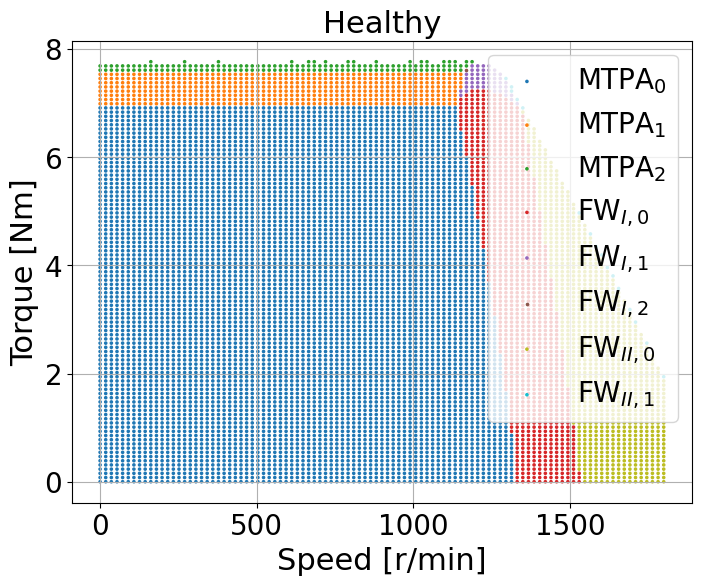

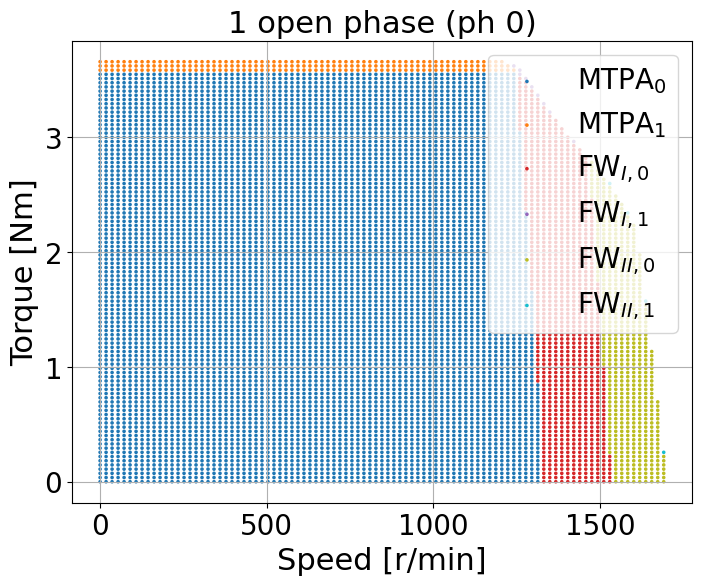

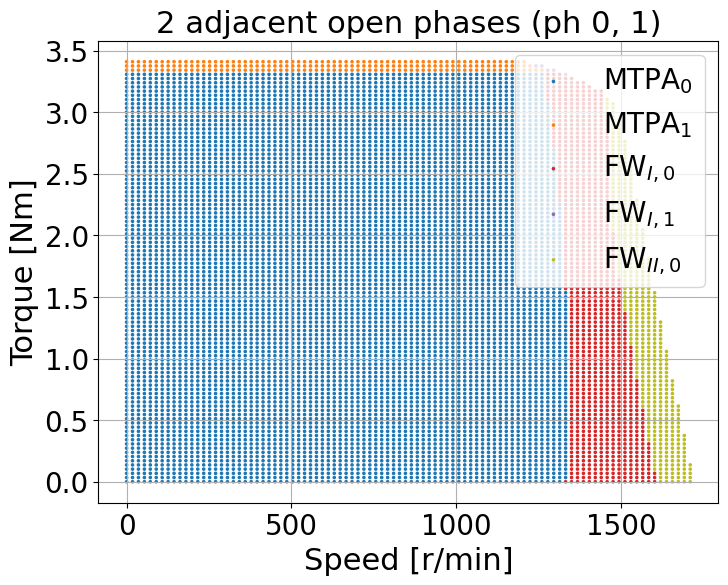

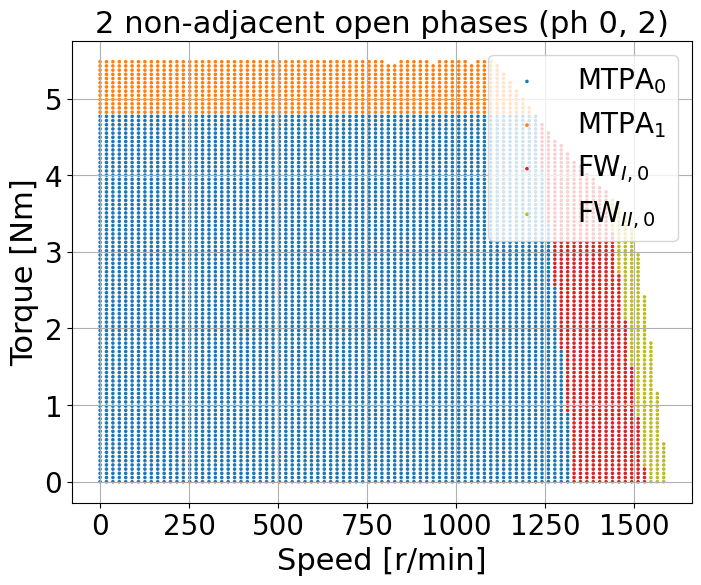

In [4]:
TITLES = {
    "healthy":        "Healthy",
    "fault_1ph":      "1 open phase (ph 0)",
    "fault_2ph_adj":  "2 adjacent open phases (ph 0, 1)",
    "fault_2ph_nadj": "2 non-adjacent open phases (ph 0, 2)",
}

for name, grid in grids.items():
    data = grid_to_data(grid, k_skip=1)
    plot_grid_segments(data, title=TITLES[name])